In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [9]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:
# Check the size of the dataset
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check data types and non-null values
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
df.describe()

Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [13]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate Rows: 0


In [15]:
# Check unique values in important categorical columns

print("Ship Mode:")
print(df['Ship Mode'].value_counts())

print("\nSegment:")
print(df['Segment'].value_counts())

print("\nCategory:")
print(df['Category'].value_counts())

print("\nRegion:")
print(df['Region'].value_counts())

Ship Mode:
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

Segment:
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

Category:
Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Region:
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64


In [17]:
# Check missing values in each column
missing_values = df.isnull().sum()

print(missing_values)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [19]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [21]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [25]:
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [27]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [29]:
df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (9994, 21)
Cleaned dataset shape: (9994, 21)


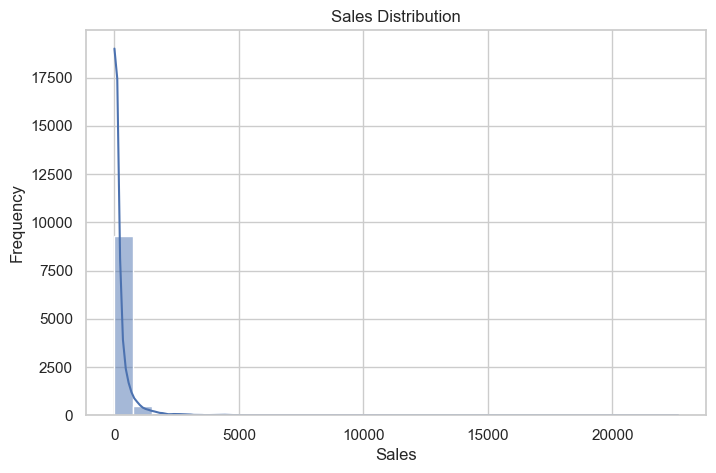

In [31]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Sales'], bins=30, kde=True)

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

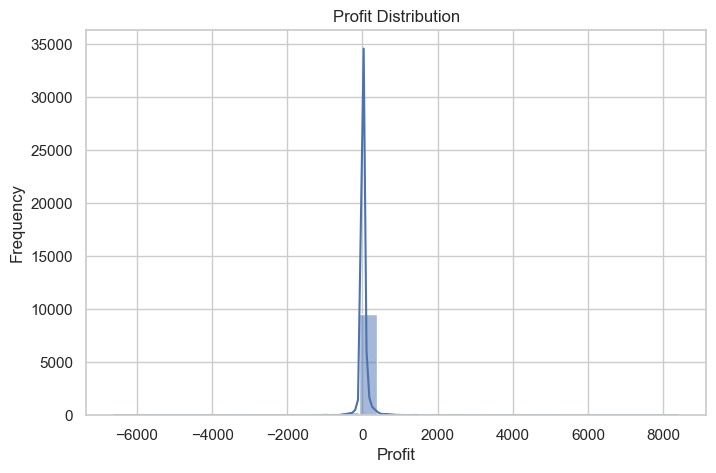

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Profit'], bins=30, kde=True)

plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Frequency')

plt.show()

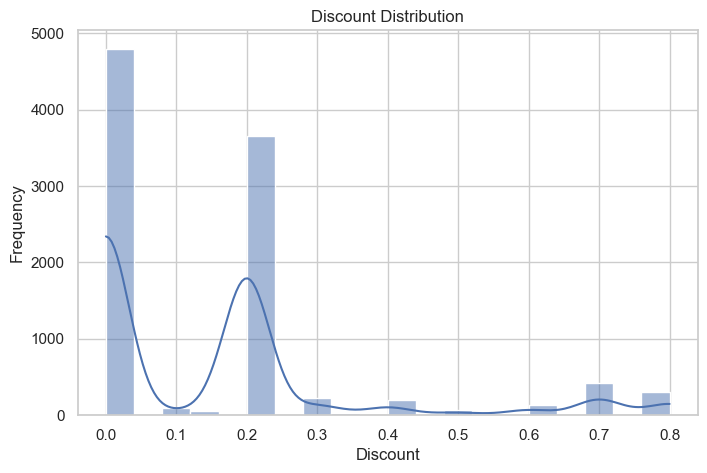

In [35]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Discount'], bins=20, kde=True)

plt.title('Discount Distribution')
plt.xlabel('Discount')
plt.ylabel('Frequency')

plt.show()

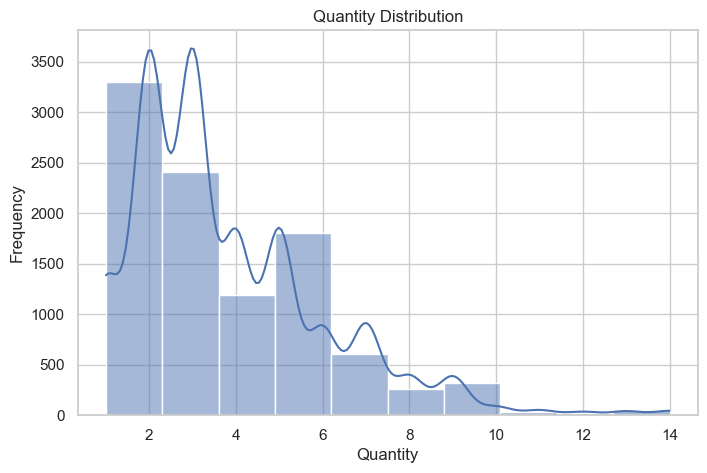

In [37]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Quantity'], bins=10, kde=True)

plt.title('Quantity Distribution')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.show()

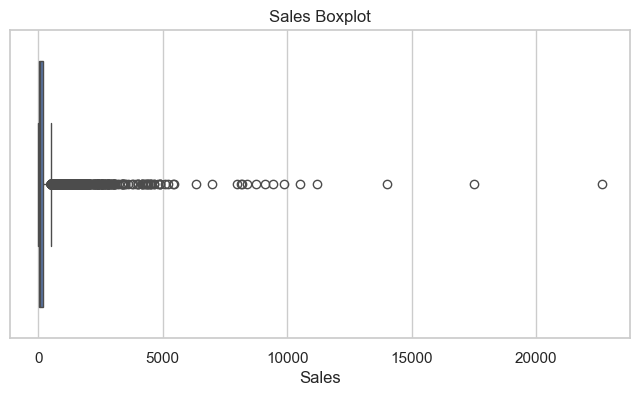

In [39]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['Sales'])

plt.title('Sales Boxplot')
plt.xlabel('Sales')

plt.show()

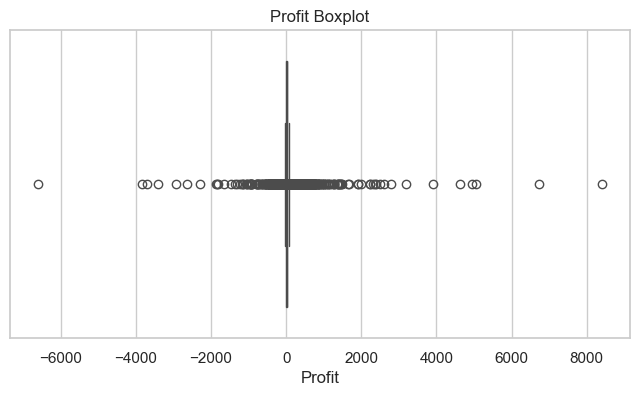

In [41]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['Profit'])

plt.title('Profit Boxplot')
plt.xlabel('Profit')

plt.show()

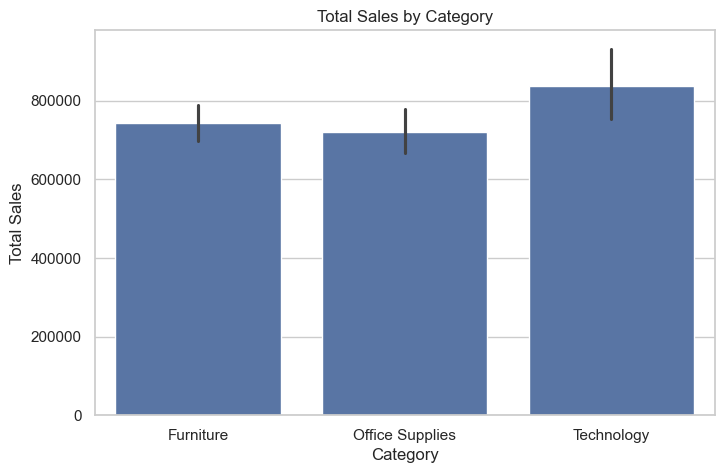

In [43]:
plt.figure(figsize=(8, 5))

sns.barplot(data=df, x='Category', y='Sales', estimator='sum')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

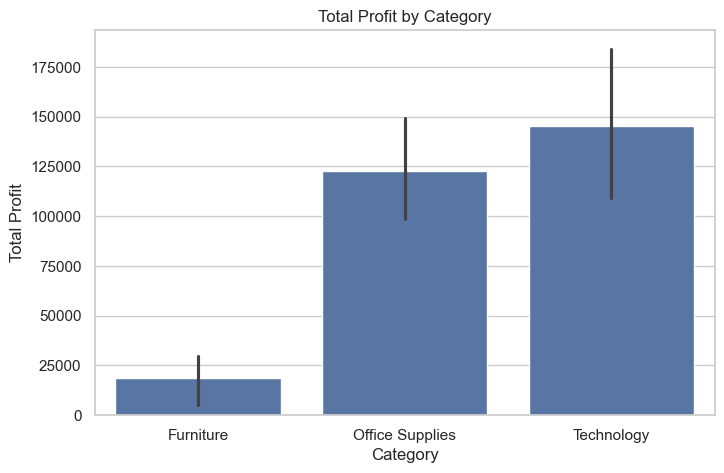

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(data=df, x='Category', y='Profit', estimator='sum')

plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')

plt.show()

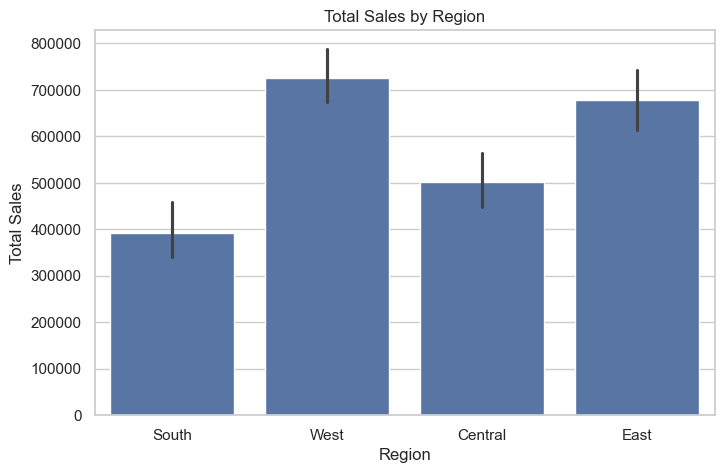

In [47]:
plt.figure(figsize=(8, 5))

sns.barplot(data=df, x='Region', y='Sales', estimator='sum')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.show()

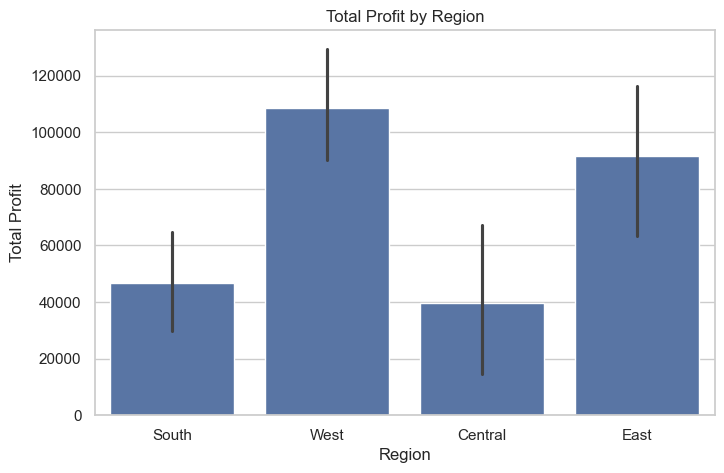

In [49]:
plt.figure(figsize=(8, 5))

sns.barplot(data=df, x='Region', y='Profit', estimator='sum')

plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')

plt.show()

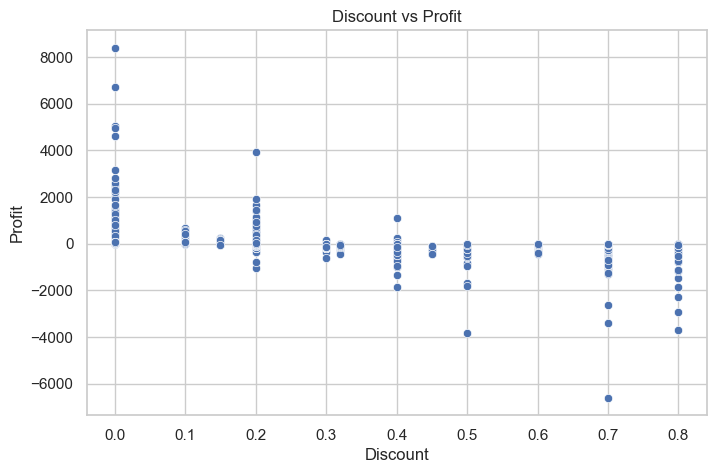

In [51]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='Discount', y='Profit')

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()

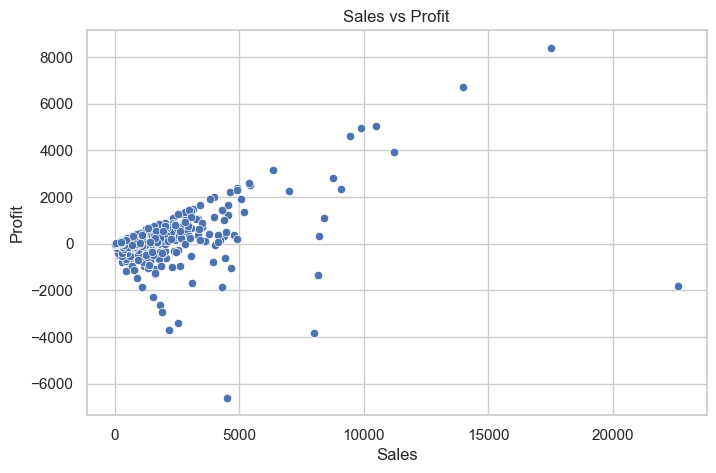

In [53]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='Sales', y='Profit')

plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')

plt.show()

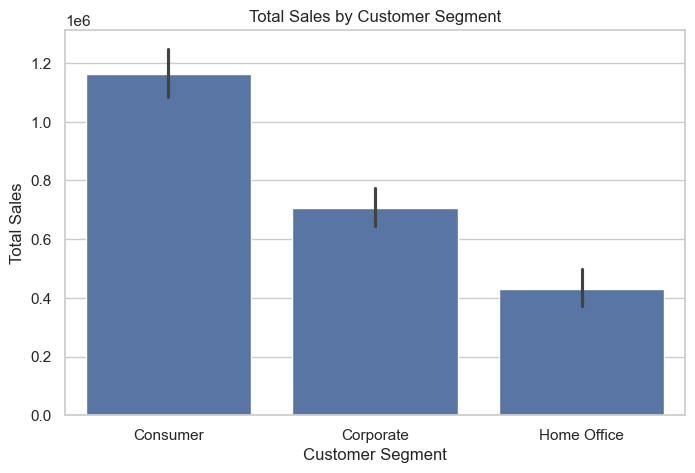

In [55]:
plt.figure(figsize=(8, 5))

sns.barplot(data=df, x='Segment', y='Sales', estimator='sum')

plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')

plt.show()

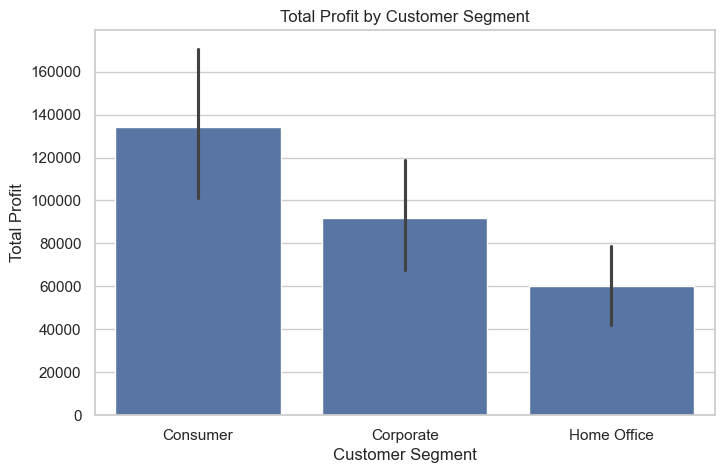

In [57]:
plt.figure(figsize=(8, 5))

sns.barplot(data=df, x='Segment', y='Profit', estimator='sum')

plt.title('Total Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Profit')

plt.show()

In [59]:
# Select important numerical columns
numeric_df = df[['Sales', 'Quantity', 'Discount', 'Profit']]

numeric_df.head()

,Sales,Quantity,Discount,Profit
0,261.9600,2,0.00,41.9136
1,731.9400,3,0.00,219.5820
2,14.6200,2,0.00,6.8714
3,957.5775,5,0.45,-383.0310
4,22.3680,2,0.20,2.5164


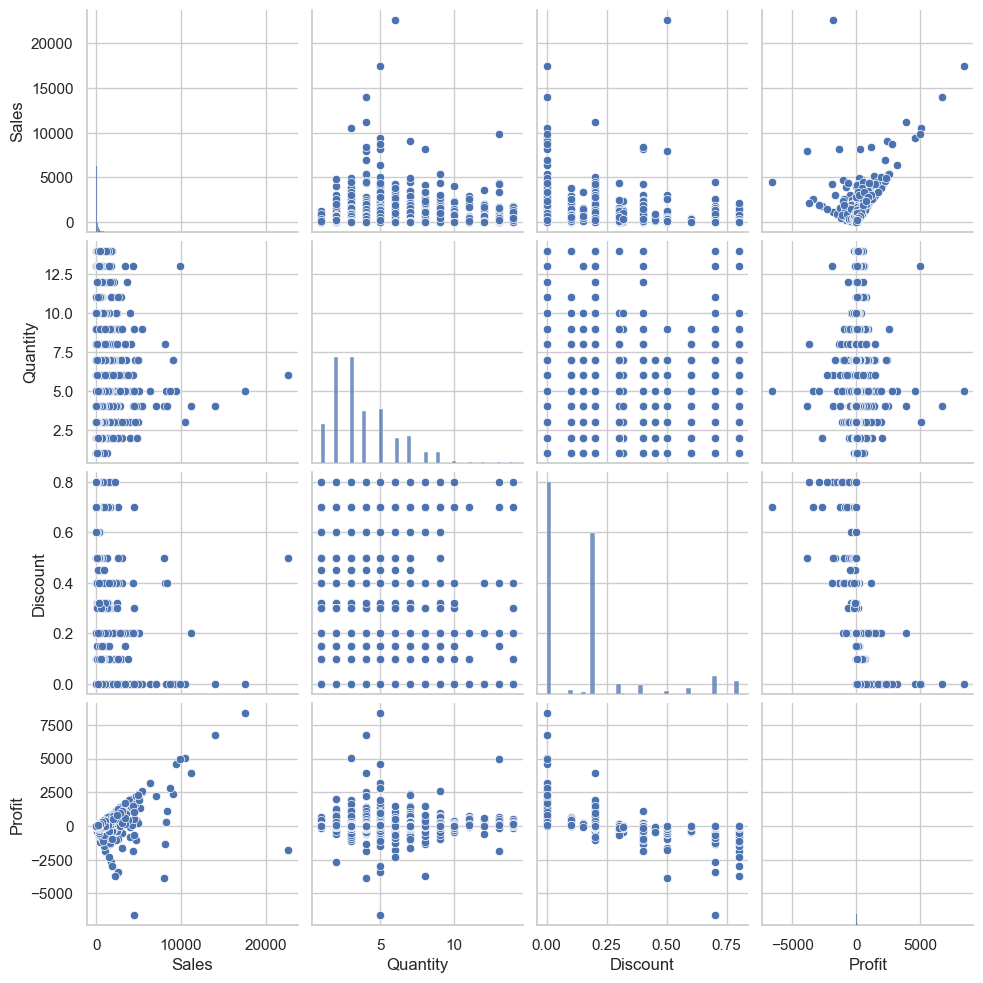

In [62]:
sns.pairplot(numeric_df)

plt.show()

In [64]:
correlation_matrix = numeric_df.corr()

correlation_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


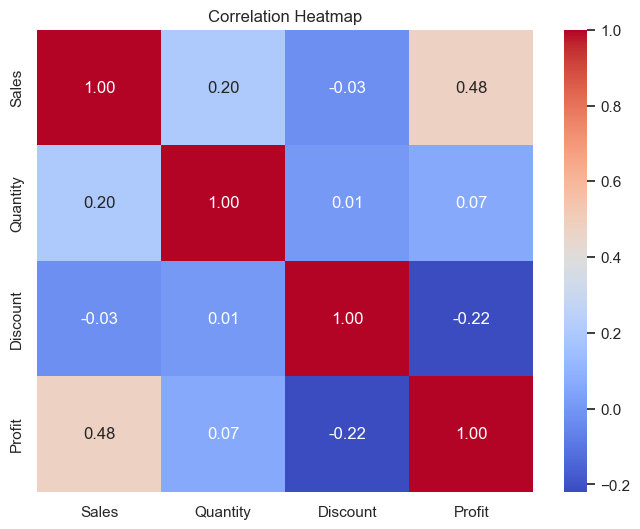

In [66]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [68]:
correlation_pairs = correlation_matrix.unstack()

correlation_pairs = correlation_pairs[
    correlation_pairs.index.get_level_values(0) != 
    correlation_pairs.index.get_level_values(1)
]

correlation_pairs.abs().sort_values(ascending=False).head(10)

Sales     Profit      0.479064
Profit    Sales       0.479064
Discount  Profit      0.219487
Profit    Discount    0.219487
Sales     Quantity    0.200795
Quantity  Sales       0.200795
          Profit      0.066253
Profit    Quantity    0.066253
Sales     Discount    0.028190
Discount  Sales       0.028190
dtype: float64

In [71]:
category_region_profit = pd.pivot_table(
    df,
    values='Profit',
    index='Category',
    columns='Region',
    aggfunc='sum'
)

category_region_profit

Region,Central,East,South,West
Category,,,,
Furniture,-2871.0494,3046.1658,6771.2061,11504.9503
Office Supplies,8879.9799,41014.5791,19986.3928,52609.8490
Technology,33697.4320,47462.0351,19991.8314,44303.6496


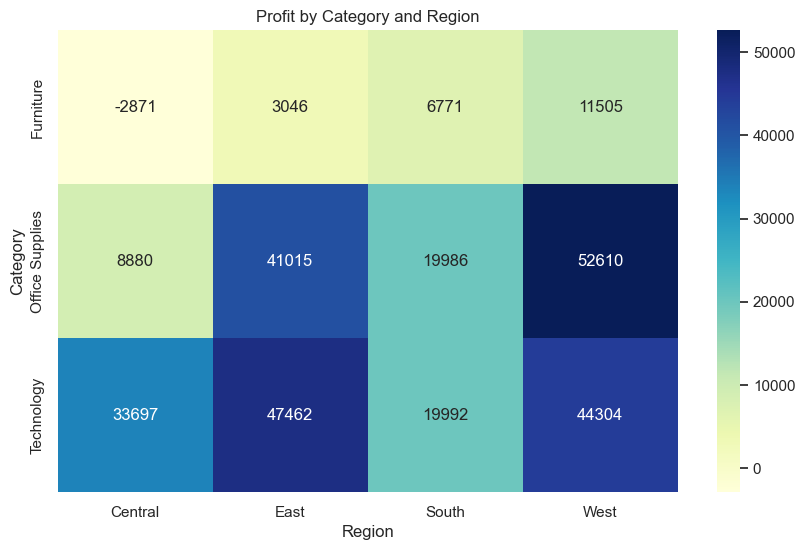

In [73]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    category_region_profit,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title('Profit by Category and Region')
plt.xlabel('Region')
plt.ylabel('Category')

plt.show()

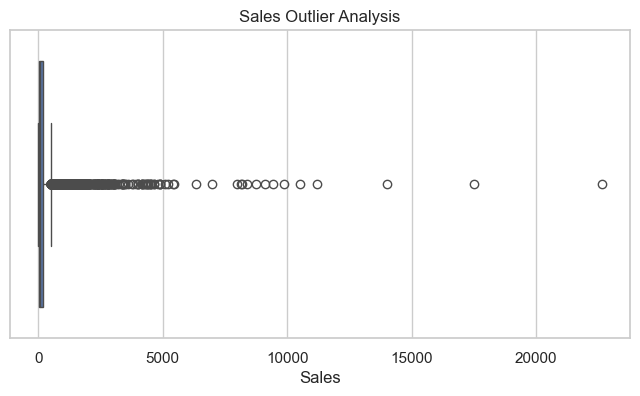

In [75]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['Sales'])

plt.title('Sales Outlier Analysis')
plt.xlabel('Sales')

plt.show()

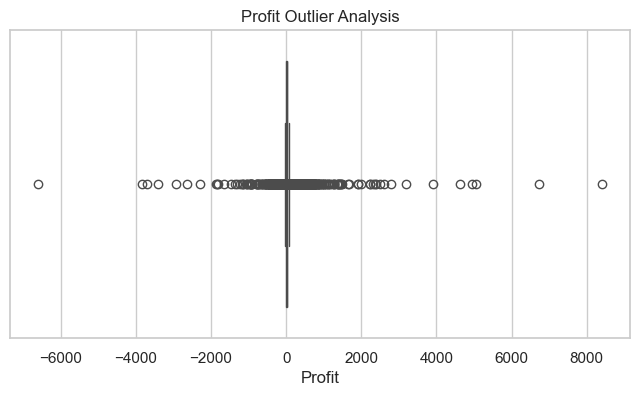

In [77]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['Profit'])

plt.title('Profit Outlier Analysis')
plt.xlabel('Profit')

plt.show()

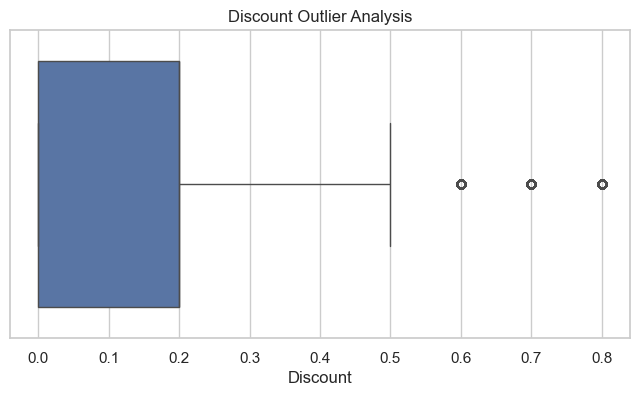

In [79]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['Discount'])

plt.title('Discount Outlier Analysis')
plt.xlabel('Discount')

plt.show()

In [81]:
# Create time-based columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()

df[['Order Date', 'Year', 'Month', 'Month_Name']].head()

,Order Date,Year,Month,Month_Name
0,2016-11-08,2016,11,November
1,2016-11-08,2016,11,November
2,2016-06-12,2016,6,June
3,2015-10-11,2015,10,October
4,2015-10-11,2015,10,October


In [83]:
yearly_sales = df.groupby('Year')['Sales'].sum()

yearly_sales

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

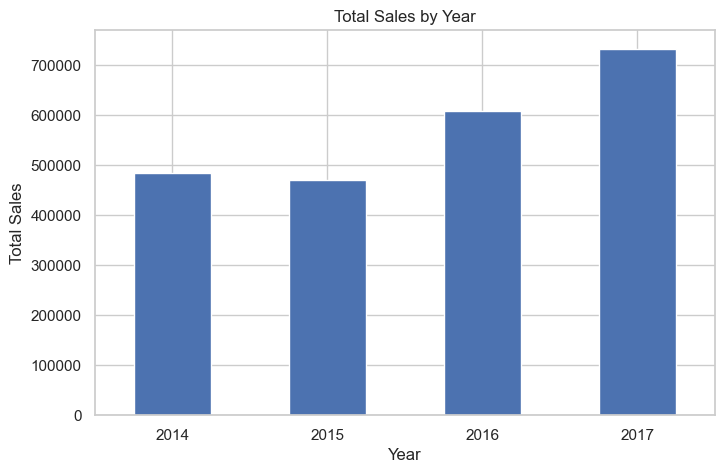

In [85]:
plt.figure(figsize=(8, 5))

yearly_sales.plot(kind='bar')

plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)
plt.show()

In [87]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.head()

Order Date
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: Sales, dtype: float64

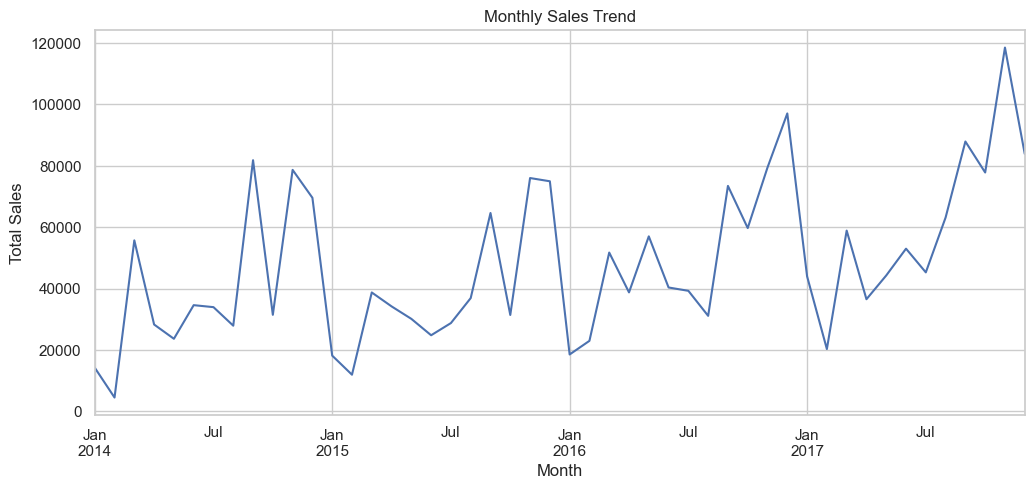

In [89]:
plt.figure(figsize=(12, 5))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.show()

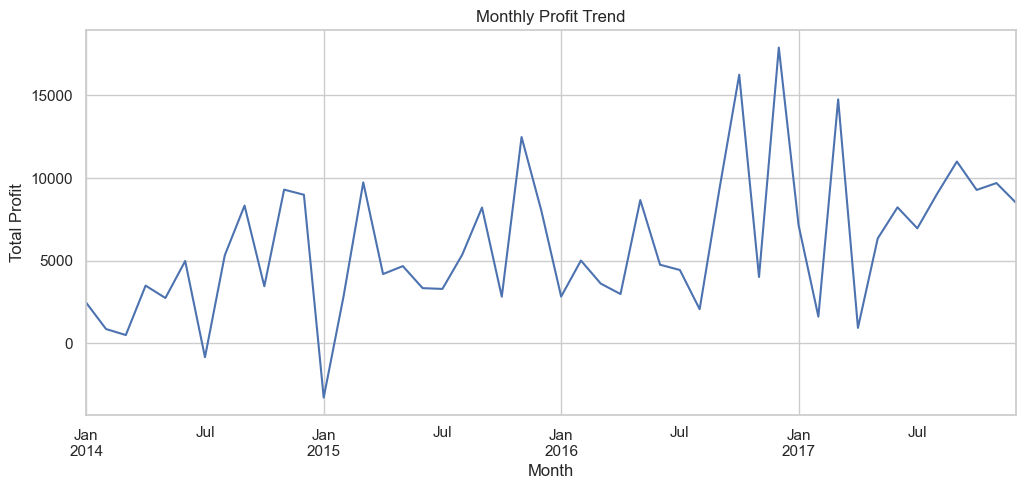

In [91]:
monthly_profit = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Profit'].sum()

plt.figure(figsize=(12, 5))

monthly_profit.plot()

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Total Profit')

plt.show()

In [93]:
top_products_sales = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_sales

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

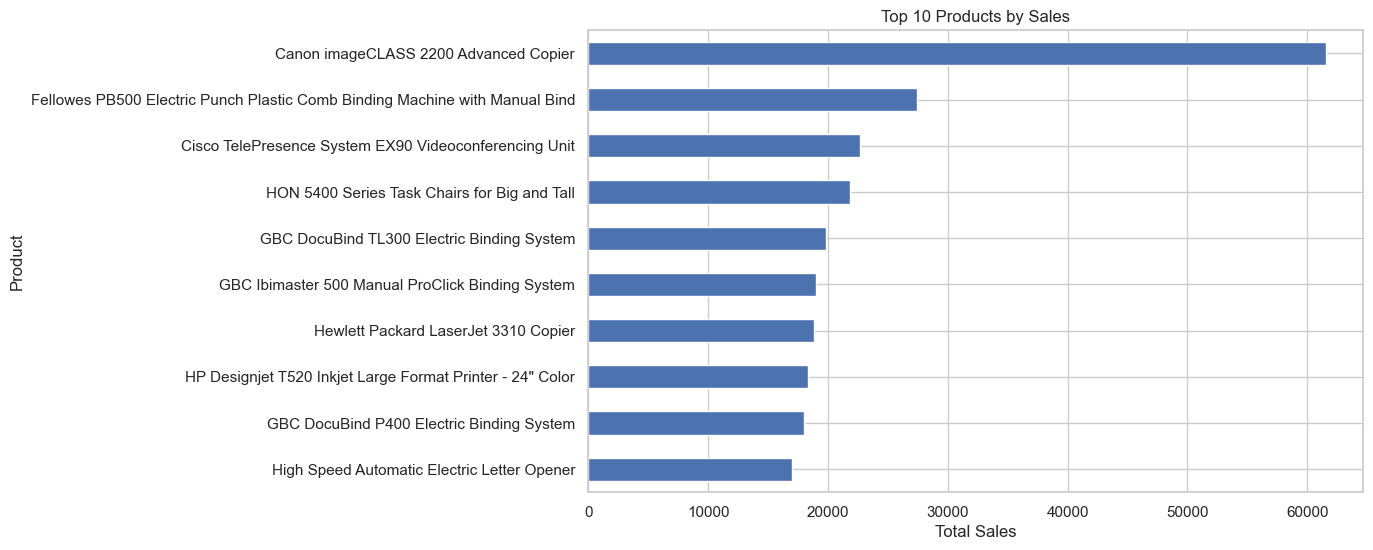

In [95]:
plt.figure(figsize=(10, 6))

top_products_sales.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')

plt.show()

In [97]:
bottom_products_profit = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

bottom_products_profit

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

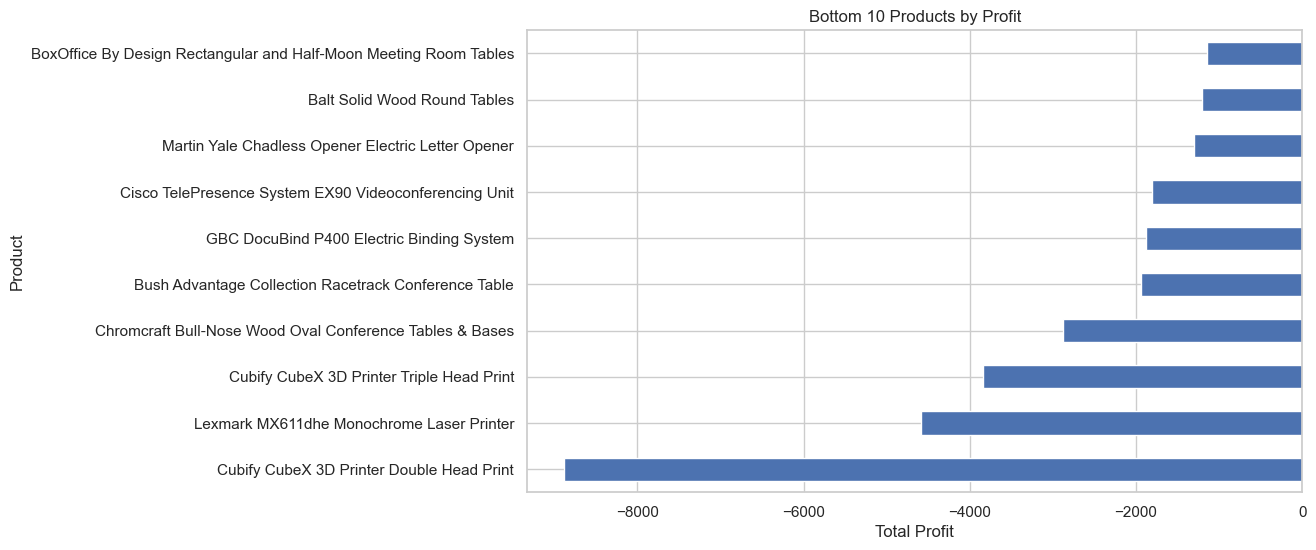

In [99]:
plt.figure(figsize=(10, 6))

bottom_products_profit.plot(kind='barh')

plt.title('Bottom 10 Products by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product')

plt.show()

# Key Findings

Based on the exploratory analysis:

1. Sales performance varies across product categories and regions.
2. Profitability differs from sales performance, showing that high sales do not necessarily guarantee high profit.
3. Discount levels have an important relationship with profitability.
4. Customer segments contribute differently to overall sales and profit.
5. The distribution analysis identifies potential outliers in sales, profit, and discount.
6. Monthly analysis reveals variations in sales and profit over time.
7. Product-level analysis identifies high-performing products and products with weak profitability.
8. Correlation analysis helps identify relationships among the major numerical variables.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (9994, 21)


In [5]:
print("Total Sales:", round(df['Sales'].sum(), 2))
print("Total Profit:", round(df['Profit'].sum(), 2))
print("Total Quantity:", df['Quantity'].sum())
print("Total Orders:", df['Order ID'].nunique())
print("Total Customers:", df['Customer ID'].nunique())

Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity: 37873
Total Orders: 5009
Total Customers: 793


In [7]:
category_summary = df.groupby('Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).sort_values('Sales', ascending=False)

category_summary

,Sales,Profit,Quantity
Category,,,
Technology,836154.0330,145454.9481,6939
Furniture,741999.7953,18451.2728,8028
Office Supplies,719047.0320,122490.8008,22906


In [9]:
print("Total Sales:", round(df['Sales'].sum(), 2))
print("Total Profit:", round(df['Profit'].sum(), 2))
print("Total Quantity:", df['Quantity'].sum())
print("Total Orders:", df['Order ID'].nunique())
print("Total Customers:", df['Customer ID'].nunique())

Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity: 37873
Total Orders: 5009
Total Customers: 793


In [11]:
category_summary = df.groupby('Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).sort_values('Sales', ascending=False)

category_summary

,Sales,Profit,Quantity
Category,,,
Technology,836154.0330,145454.9481,6939
Furniture,741999.7953,18451.2728,8028
Office Supplies,719047.0320,122490.8008,22906


In [13]:
region_summary = df.groupby('Region').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).sort_values('Sales', ascending=False)

region_summary

,Sales,Profit,Quantity
Region,,,
West,725457.8245,108418.4489,12266
East,678781.2400,91522.7800,10618
Central,501239.8908,39706.3625,8780
South,391721.9050,46749.4303,6209


In [15]:
discount_summary = df.groupby('Discount').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).sort_index()

discount_summary

,Sales,Profit
Discount,,
0.00,1.087908e+06,320987.6032
0.10,5.436935e+04,9029.1770
0.15,2.755852e+04,1418.9915
0.20,7.645944e+05,90337.3060
0.30,1.032267e+05,-10369.2774
0.32,1.449346e+04,-2391.1377
0.40,1.164178e+05,-23057.0504
0.45,5.484974e+03,-2493.1111
0.50,5.891854e+04,-20506.4281


In [17]:
top_5_sales = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_5_sales

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

In [19]:
bottom_5_profit = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values()
    .head(5)
)

bottom_5_profit

Product Name
Cubify CubeX 3D Printer Double Head Print                  -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                  -4589.9730
Cubify CubeX 3D Printer Triple Head Print                  -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.1156
Bush Advantage Collection Racetrack Conference Table       -1934.3976
Name: Profit, dtype: float64

# Conclusion

The Exploratory Data Analysis of the Superstore dataset was performed using Python, Pandas, NumPy, Matplotlib, and Seaborn.

The analysis explored sales, profit, quantity, discount, customer segments, product categories, regions, and time-based performance. Statistical summaries and visualizations were used to identify patterns, relationships, trends, and potential outliers.

The analysis provides useful insights into business performance and helps identify high-performing categories, regions, customer segments, and products, as well as areas where profitability can be improved.

Overall, this project demonstrates how Exploratory Data Analysis can transform raw business data into meaningful insights that support data-driven decision-making.